# Preprocessing Data

In [1]:
# import
import os
import re
import csv
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from io import StringIO
from urllib.request import urlopen

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

In [2]:
# Data path
true_path = r'..\Data\True.csv'
fake_path = r'..\Data\Fake.csv'

In [3]:
# Read csv
data_true = pd.read_csv(true_path)
data_fake = pd.read_csv(fake_path)

In [4]:
data_true['class'] = 1
data_fake['class'] = 0

In [5]:
data = pd.concat([data_true, data_fake], axis= 0)
data.sample(5)

,title,text,subject,date,class
4621,Exclusive: As Democratic attorneys general tar...,(Reuters) - For years the national political o...,politicsNews,"March 28, 2017",1
13264,BREAKING BOMBSHELL: All Dem Congressmen Phone ...,Wow! This just keeps getting better and better...,politics,"Aug 12, 2016",0
14634,EYE-OPENING: Why Liberals Won’t Talk About Whi...,This is a story you will never find in the mai...,politics,"Jan 18, 2016",0
5782,Pastor Who Prayed For Deaths Of Orlando Survi...,Pastor Roger Jimenez made national news after ...,News,"June 21, 2016",0
21487,FLASHBACK: UNCOVERED VIDEO SHOWS HYPOCRITE HAR...,In 1993 Harry Reid wrote the Immigration Stabi...,left-news,"Aug 23, 2015",0


In [6]:
# Information about data
print("Thông tin dữ liệu:")
display(data.info())

print("\n5 dòng đầu:")
display(data.head())

print("\nTên cột:")
print(data.columns.tolist())

print("\nSố lượng giá trị thiếu:")
print(data.isna().sum())


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   class    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


None


5 dòng đầu:


,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1



Tên cột:
['title', 'text', 'subject', 'date', 'class']

Số lượng giá trị thiếu:
title      0
text       0
subject    0
date       0
class      0
dtype: int64


In [7]:
# pre clean data
data['content'] = data['title'] + ' ' +data['text']
data.drop(['title', 'subject', 'date', 'text'], axis=1, inplace=True)
data.sample(5)

,class,content
11983,1,Markets cheer as Chile's Pinera gets strong ma...
7812,0,Comedy Icon Dick Van Dyke’s First Endorsement...
23061,0,EP #9: Patrick Henningsen LIVE – ‘Our Western ...
20448,0,WATCH THIS: DID GOOGLE MANIPULATE Search For H...
14713,1,Thai court looks into lawsuit against owner of...


In [8]:

data = data.drop_duplicates(subset=['content']).reset_index(drop=True)

print("Số dòng sau khi xóa trùng:", len(data))

Số dòng sau khi xóa trùng: 39105


In [9]:
data.reset_index(inplace= True)
data.sample(5)

,index,class,content
28284,28284,0,WATCH: Samantha Bee Shows Just How CRAZY Ted ...
14938,14938,1,France's Macron treads fine line in Iran-Saudi...
9080,9080,1,Russians steal research on Trump in hack of U....
8006,8006,1,Trump doubles down on 'law-and-order' appeal i...
7618,7618,1,Ex-Miss Finland says Trump groped her HELSINKI...


In [10]:
data.drop(['index'], axis=1, inplace= True)
data.sample(5)

,class,content
16306,1,Islamic State claims deadly attack on Libyan c...
31334,0,CNN’S VAN JONES FAKE CRYING Over Trump Blaming...
15739,1,"South Sudan media regulator bans press groups,..."
5920,1,Trump says he had 'very good' call with Mexico...
21084,1,Ireland calls for realism from UK on border is...


In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text)
    
    text = text.lower()
    
    text = re.sub(r'http\S+|www\S+', '', text)
    
    text = re.sub(r'\S+@\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    
    return ' '.join(tokens)



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [12]:
data["content"] = data["content"].apply(preprocess_text)

In [13]:
data.sample(5)

,class,content
24694,0,canadian hilariously humiliates three trump su...
31281,0,watch first family arrive back dcpresident tru...
21516,0,zuckerberg personally warned russian meddling ...
3307,1,trump aide tell keep session u attorney genera...
33341,0,breaking liberal head explode find cabinet pos...


In [14]:
# slplit train and test.
x = data['content']
y = data['class']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size= 0.25,
    random_state= 42, stratify=y
)

In [15]:
label_names = {
    1 : 'True New',
    0 : 'Fake New'
}
print("Số mẫu train:", len(x_train))
print("Số mẫu test:", len(x_test))

print("\nPhân bố nhãn train:")
print(y_train.value_counts().sort_index().rename(index=label_names))
 
print("\nPhân bố nhãn test:")
print(y_test.value_counts().sort_index().rename(index=label_names))

Số mẫu train: 29328
Số mẫu test: 9777

Phân bố nhãn train:
class
Fake New    13431
True New    15897
Name: count, dtype: int64

Phân bố nhãn test:
class
Fake New    4477
True New    5300
Name: count, dtype: int64


# SVM Linear Algorithm


SVM Linear

In [16]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features= 20000,
        ngram_range= (1, 2),
        min_df=2, 
        max_df=0.95,
        sublinear_tf= True
    )),
    ('svm', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
svm_pipeline.fit(x_train, y_train)

y_pred_svm = svm_pipeline.predict(x_test)

print("Result of SVM Linear:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=['Fake', 'Real'],
    zero_division= 0,
    digits= 6
))

Result of SVM Linear:
              precision    recall  f1-score   support

        Fake   0.997985  0.995533  0.996757      4477
        Real   0.996234  0.998302  0.997267      5300

    accuracy                       0.997034      9777
   macro avg   0.997110  0.996917  0.997012      9777
weighted avg   0.997036  0.997034  0.997034      9777



Optimazing Model SVM with GridSearchCV

In [17]:
param_grid = {
    "tfidf__max_features": [5000, 10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "svm__C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Tham số tốt nhất:")
print(grid_search.best_params_)

print("\nF1-score trung bình tốt nhất trên cross-validation:")
print(grid_search.best_score_)

best_svm_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Tham số tốt nhất:
{'svm__C': 1, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

F1-score trung bình tốt nhất trên cross-validation:
0.9968583940757156


Evaluate model after optimazing

In [18]:
y_pred_best_svm = best_svm_model.predict(x_test)

svm_accuracy = accuracy_score(y_test, y_pred_best_svm)
svm_precision = precision_score(y_test, y_pred_best_svm, zero_division=0)
svm_recall = recall_score(y_test, y_pred_best_svm, zero_division=0)
svm_f1 = f1_score(y_test, y_pred_best_svm, zero_division=0)

print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1-score:", svm_f1)

print("\nResult:")
print(classification_report(
    y_test,
    y_pred_best_svm,
    target_names=["Fake", "Real"],
    zero_division=0,
    digits=6
))

Accuracy: 0.9970338549657359
Precision: 0.9960474308300395
Recall: 0.9984905660377359
F1-score: 0.9972675021200414

Result:
              precision    recall  f1-score   support

        Fake   0.998208  0.995309  0.996757      4477
        Real   0.996047  0.998491  0.997268      5300

    accuracy                       0.997034      9777
   macro avg   0.997128  0.996900  0.997012      9777
weighted avg   0.997037  0.997034  0.997034      9777



Confusion matrix

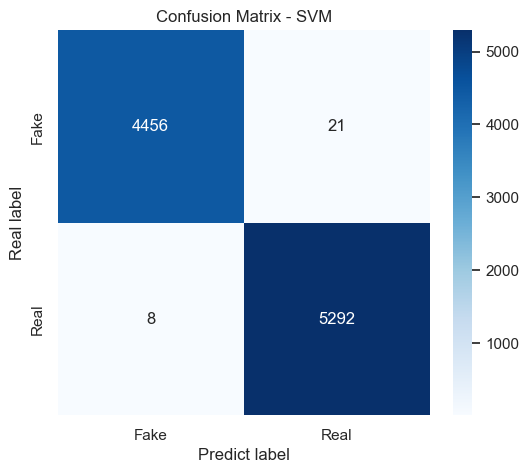

In [19]:
cm = confusion_matrix(y_test, y_pred_best_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

# Logistic Regression

In [20]:
logistic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('logistic', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

logistic_pipeline.fit(x_train, y_train)

y_pred_logistic = logistic_pipeline.predict(x_test)

print("Result of Logistic Regression:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['Fake', 'Real'],
    zero_division=0,
    digits=6
))

Result of Logistic Regression:
              precision    recall  f1-score   support

        Fake   0.995494  0.987045  0.991252      4477
        Real   0.989135  0.996226  0.992668      5300

    accuracy                       0.992022      9777
   macro avg   0.992314  0.991636  0.991960      9777
weighted avg   0.992047  0.992022  0.992019      9777



Accuracy: 0.9920220926664621
Precision: 0.9891345073061072
Recall: 0.9962264150943396
F1-score: 0.9926677946982515


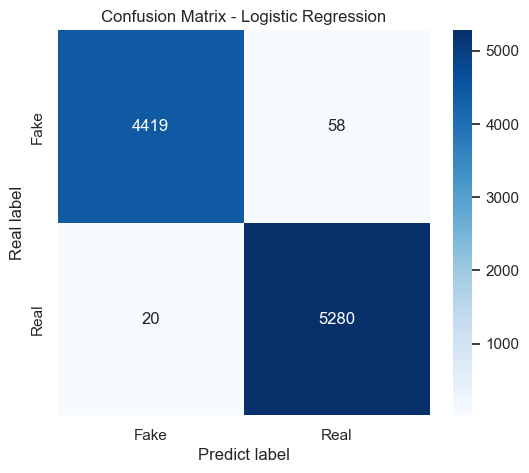

In [21]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic, zero_division=0)
logistic_recall = recall_score(y_test, y_pred_logistic, zero_division=0)
logistic_f1 = f1_score(y_test, y_pred_logistic, zero_division=0)

print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1-score:", logistic_f1)

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

## Linear SVM - From Scratch

Ý tưởng chính:

- Đổi nhãn ban đầu `0/1` thành `-1/+1`.
- Tối ưu hàm mất mát Hinge Loss
- Cập nhật trọng số bằng Mini-batch Gradient Descent
- Dự đoán theo dấu của hàm quyết định `X @ w + b`.

- 0 = Fake News
- 1 = Real News

In [22]:
class LinearSVMFromScratch:
    def __init__(
        self,
        learning_rate=0.01,
        C=1.0,
        n_epochs=50,
        batch_size=512,
        random_state=42,
        class_weight="balanced"
    ):
        self.learning_rate = learning_rate
        self.C = C
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.class_weight = class_weight
        self.w = None
        self.b = 0.0
        self.loss_history = []

    def _convert_labels(self, y):
        y = np.asarray(y)
        return np.where(y == 1, 1, -1)

    def _compute_sample_weights(self, y_signed):
        if self.class_weight != "balanced":
            return np.ones_like(y_signed, dtype=float)

        n_samples = len(y_signed)

        n_pos = np.sum(y_signed == 1)
        n_neg = np.sum(y_signed == -1)

        weight_pos = n_samples / (2 * n_pos)
        weight_neg = n_samples / (2 * n_neg)

        return np.where(y_signed == 1, weight_pos, weight_neg)

    def _compute_loss(self, X, y_signed, sample_weights):
        margins = y_signed * (X @ self.w + self.b)
        hinge_loss = np.maximum(0, 1 - margins)

        weighted_hinge_loss = np.mean(sample_weights * hinge_loss)
        regularization_loss = 0.5 * np.dot(self.w, self.w)

        return regularization_loss + self.C * weighted_hinge_loss

    def fit(self, X, y, verbose=True):
        y_signed = self._convert_labels(y)
        sample_weights = self._compute_sample_weights(y_signed)

        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)

        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []

        for epoch in range(self.n_epochs):
            indices = rng.permutation(n_samples)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]

                X_batch = X[batch_idx]
                y_batch = y_signed[batch_idx]
                weights_batch = sample_weights[batch_idx]

                margins = y_batch * (X_batch @ self.w + self.b)
                violations = margins < 1

                # Gradient regularization: chỉ áp dụng cho w, không chia batch
                w_grad = self.w.copy()
                b_grad = 0.0

                if np.any(violations):
                    X_vio = X_batch[violations]
                    y_vio = y_batch[violations]
                    w_vio = weights_batch[violations]

                    n_batch = len(batch_idx)

                    # Gradient hinge: -C * (1/n_batch) * Σ w_i * y_i * x_i
                    # Dùng w_vio * y_vio để có trọng số sample, không dùng mỗi y_vio
                    hinge_w_grad = X_vio.T @ (w_vio * y_vio)
                    hinge_w_grad = np.asarray(hinge_w_grad).ravel()
                    hinge_b_grad = np.sum(w_vio * y_vio)

                    # Chỉ phần hinge mới chia theo batch size
                    w_grad -= self.C * hinge_w_grad / n_batch
                    b_grad -= self.C * hinge_b_grad / n_batch

                self.w -= self.learning_rate * w_grad
                self.b -= self.learning_rate * b_grad

            epoch_loss = self._compute_loss(X, y_signed, sample_weights)
            self.loss_history.append(epoch_loss)

            if verbose:
                print(f"Epoch {epoch + 1}/{self.n_epochs} - Loss: {epoch_loss:.6f}")

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, 0)


In [23]:
tfidf_svm_scratch = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_scratch = tfidf_svm_scratch.fit_transform(x_train)
X_test_scratch = tfidf_svm_scratch.transform(x_test)

svm_scratch = LinearSVMFromScratch(
    learning_rate=0.01,
    C=10.0,
    n_epochs=50,
    batch_size=512,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

svm_scratch.fit(X_train_scratch, y_train, verbose=True)

y_pred_svm_scratch = svm_scratch.predict(X_test_scratch)

print("Số lượng nhãn dự đoán:")
print(pd.Series(y_pred_svm_scratch).value_counts().sort_index())

print("\nResult of Linear SVM From Scratch:")
print(classification_report(
    y_test,
    y_pred_svm_scratch,
    target_names=["Fake", "Real"],
    zero_division=0,
    digits=6
))

Epoch 1/50 - Loss: 9.795905
Epoch 2/50 - Loss: 9.732278
Epoch 3/50 - Loss: 9.712317
Epoch 4/50 - Loss: 9.706147
Epoch 5/50 - Loss: 9.704224
Epoch 6/50 - Loss: 9.703624
Epoch 7/50 - Loss: 9.703434
Epoch 8/50 - Loss: 9.703369
Epoch 9/50 - Loss: 9.703353
Epoch 10/50 - Loss: 9.703347
Epoch 11/50 - Loss: 9.703340
Epoch 12/50 - Loss: 9.703339
Epoch 13/50 - Loss: 9.703340
Epoch 14/50 - Loss: 9.703340
Epoch 15/50 - Loss: 9.703341
Epoch 16/50 - Loss: 9.703337
Epoch 17/50 - Loss: 9.703336
Epoch 18/50 - Loss: 9.703338
Epoch 19/50 - Loss: 9.703342
Epoch 20/50 - Loss: 9.703337
Epoch 21/50 - Loss: 9.703337
Epoch 22/50 - Loss: 9.703338
Epoch 23/50 - Loss: 9.703337
Epoch 24/50 - Loss: 9.703341
Epoch 25/50 - Loss: 9.703338
Epoch 26/50 - Loss: 9.703335
Epoch 27/50 - Loss: 9.703342
Epoch 28/50 - Loss: 9.703339
Epoch 29/50 - Loss: 9.703338
Epoch 30/50 - Loss: 9.703338
Epoch 31/50 - Loss: 9.703338
Epoch 32/50 - Loss: 9.703341
Epoch 33/50 - Loss: 9.703339
Epoch 34/50 - Loss: 9.703343
Epoch 35/50 - Loss: 9.7

Accuracy: 0.7391837987112612
Precision: 0.6751592356687898
Recall: 1.0
F1-score: 0.8060836501901141


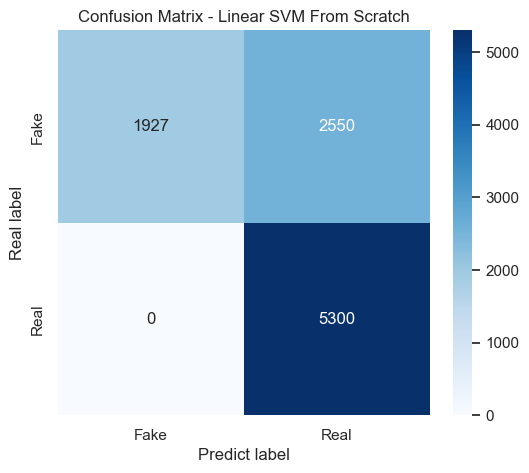

In [24]:
svm_scratch_accuracy = accuracy_score(y_test, y_pred_svm_scratch)
svm_scratch_precision = precision_score(y_test, y_pred_svm_scratch, zero_division=0)
svm_scratch_recall = recall_score(y_test, y_pred_svm_scratch, zero_division=0)
svm_scratch_f1 = f1_score(y_test, y_pred_svm_scratch, zero_division=0)

print("Accuracy:", svm_scratch_accuracy)
print("Precision:", svm_scratch_precision)
print("Recall:", svm_scratch_recall)
print("F1-score:", svm_scratch_f1)

cm_svm_scratch = confusion_matrix(y_test, y_pred_svm_scratch)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm_scratch,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Confusion Matrix - Linear SVM From Scratch")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

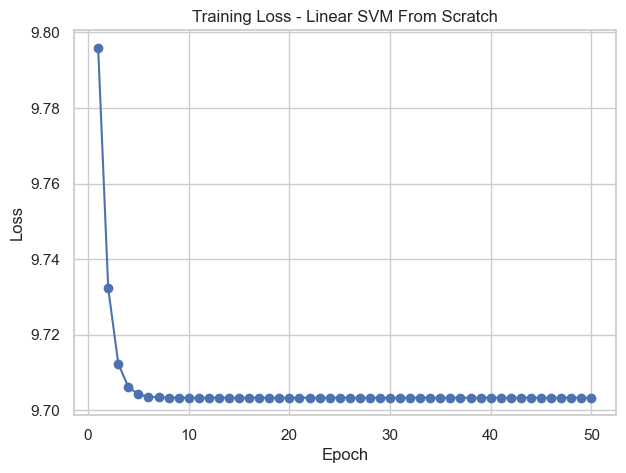

In [25]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(svm_scratch.loss_history) + 1), svm_scratch.loss_history, marker='o')
plt.title("Training Loss - Linear SVM From Scratch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# So sánh kết quả mô hình

In [26]:
comparison_results = pd.DataFrame([
    {
        "Model": "Linear SVM (library)",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1-score": svm_f1
    },
    {
        "Model": "Logistic Regression (library)",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1-score": logistic_f1
    },
    {
        "Model": "Linear SVM (from scratch)",
        "Accuracy": svm_scratch_accuracy,
        "Precision": svm_scratch_precision,
        "Recall": svm_scratch_recall,
        "F1-score": svm_scratch_f1
    }
])

comparison_results

,Model,Accuracy,Precision,Recall,F1-score
0,Linear SVM (library),0.997034,0.996047,0.998491,0.997268
1,Logistic Regression (library),0.992022,0.989135,0.996226,0.992668
2,Linear SVM (from scratch),0.739184,0.675159,1.000000,0.806084


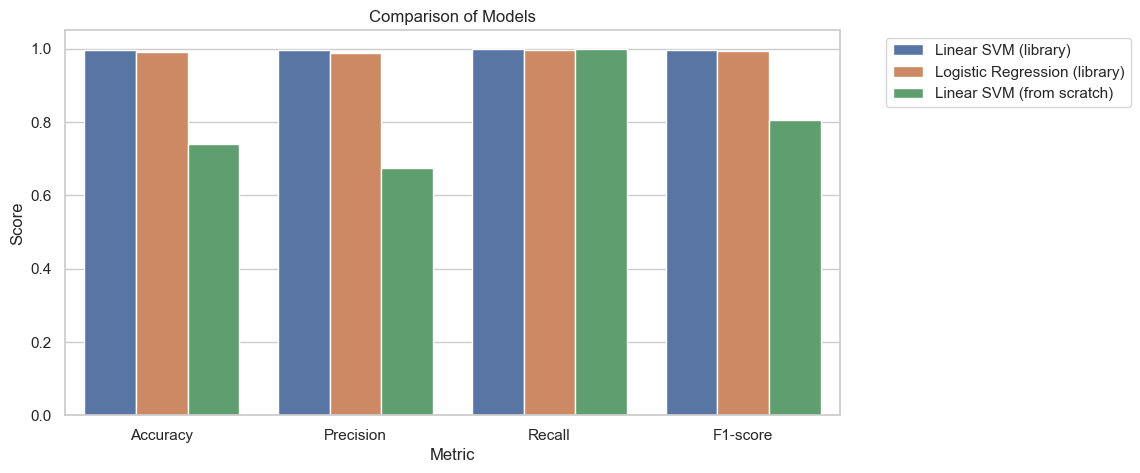

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparison_results.melt(id_vars="Model", var_name="Metric", value_name="Score"),
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("Comparison of Models")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [28]:
# Lưu model SVM tốt nhất, gồm cả TF-IDF + LinearSVC
joblib.dump(best_svm_model, "svm_pipeline_model_1.jb")

print("Đã lưu model vào:svm_pipeline_model_1.jb")

Đã lưu model vào:svm_pipeline_model_1.jb


# Phân tích các mẫu dự đoán sai

In [29]:
import re
import numpy as np
import pandas as pd
from IPython.display import display, HTML


# =========================
# 1. Tạo DataFrame chứa các mẫu dự đoán sai
# =========================

error_df = pd.DataFrame({
    "text": x_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "pred_label": pd.Series(y_pred_best_svm).reset_index(drop=True)
})

# Chỉ lấy những mẫu mô hình dự đoán sai
error_df = error_df[error_df["true_label"] != error_df["pred_label"]].copy()

label_name = {
    0: "Fake News",
    1: "Real News"
}
print("0 = Fake News " \
"      1 = Real News")
print("\nTổng số mẫu dự đoán sai:", len(error_df))
print("\n5 mẫu đầu tiên trong", len(error_df),"mẫu sai là: ")
display(error_df.head())


# =========================
# 2. Hàm lấy từ/cụm từ làm mô hình nghiêng về nhãn đã dự đoán
# =========================

def get_vectorizer_and_classifier(pipeline_model):
    """
    Lấy TF-IDF vectorizer và classifier cuối cùng từ Pipeline.
    Dùng được cho Pipeline dạng:
    Pipeline([
        ('tfidf', TfidfVectorizer(...)),
        ('svm', LinearSVC(...))
    ])
    """

    tfidf = None

    for name, step in pipeline_model.named_steps.items():
        if hasattr(step, "get_feature_names_out") and hasattr(step, "transform"):
            tfidf = step
            break

    classifier = pipeline_model.steps[-1][1]

    return tfidf, classifier


def get_words_supporting_prediction(pipeline_model, text, predicted_label, top_n=8):
    """
    Lấy các từ/cụm từ trong văn bản làm mô hình nghiêng về nhãn predicted_label.

    Quy ước:
    0 = Fake News
    1 = Real News

    Với LinearSVC:
    - contribution dương thường nghiêng về class 1
    - contribution âm thường nghiêng về class 0
    """

    tfidf, classifier = get_vectorizer_and_classifier(pipeline_model)

    if tfidf is None or classifier is None:
        return []

    if not hasattr(classifier, "coef_"):
        return []

    X = tfidf.transform([text])
    feature_names = tfidf.get_feature_names_out()
    coef = classifier.coef_[0]

    contributions = X.multiply(coef).toarray().ravel()
    nonzero_indices = X.nonzero()[1]

    classes = list(classifier.classes_)

    # Nếu mô hình dự đoán Real
    if predicted_label == classes[1]:
        candidates = [
            (feature_names[i], contributions[i])
            for i in nonzero_indices
            if contributions[i] > 0
        ]

    # Nếu mô hình dự đoán Fake
    else:
        candidates = [
            (feature_names[i], abs(contributions[i]))
            for i in nonzero_indices
            if contributions[i] < 0
        ]

    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)

    return candidates[:top_n]


# =========================
# 3. Hàm phân tích nguyên nhân dự đoán sai
# =========================

# =========================
# TỰ ĐỘNG LẤY TỪ NGHIÊNG VỀ FAKE / REAL TỪ MODEL
# =========================

def extract_model_keywords(pipeline_model, top_n=30):
    """
    Tự động lấy các từ/cụm từ quan trọng nhất từ mô hình Linear SVM hoặc Logistic Regression.

    Quy ước:
    0 = Fake News
    1 = Real News

    Với mô hình nhị phân:
    - coef âm mạnh  -> nghiêng về class 0, tức Fake
    - coef dương mạnh -> nghiêng về class 1, tức Real
    """

    tfidf, classifier = get_vectorizer_and_classifier(pipeline_model)

    if tfidf is None or classifier is None:
        return set(), set()

    if not hasattr(classifier, "coef_"):
        return set(), set()

    feature_names = tfidf.get_feature_names_out()
    coef = classifier.coef_[0]

    # Lấy chỉ số các trọng số nhỏ nhất: nghiêng về Fake
    fake_indices = np.argsort(coef)[:top_n]

    # Lấy chỉ số các trọng số lớn nhất: nghiêng về Real
    real_indices = np.argsort(coef)[-top_n:]

    fake_keywords = set(feature_names[fake_indices])
    real_keywords = set(feature_names[real_indices])

    return fake_keywords, real_keywords


fake_style_words, real_style_words = extract_model_keywords(
    best_svm_model,
    top_n=40
)

print("Các từ/cụm từ mô hình học là nghiêng về Fake:")
print(fake_style_words)

print("\nCác từ/cụm từ mô hình học là nghiêng về Real:")
print(real_style_words)


def count_exclamation(text):
    return text.count("!")


def count_uppercase_words(text):
    words = re.findall(r"\b[A-Z]{2,}\b", str(text))
    return len(words)


def word_count(text):
    return len(str(text).split())


def count_keyword_overlap(text, keyword_set):
    text_lower = str(text).lower()
    tokens = set(re.findall(r"\b[a-zA-Z]+\b", text_lower))
    return len(tokens.intersection(keyword_set))


def analyze_wrong_prediction_reason(text, true_label, pred_label):
    """
    Sinh ra các nhận xét giải thích vì sao mô hình có thể dự đoán sai.
    Đây là phân tích dựa trên từ khóa mà chính mô hình học được từ dữ liệu.
    """

    reasons = []

    n_words = word_count(text)
    n_exclamation = count_exclamation(text)
    n_uppercase = count_uppercase_words(text)
    fake_word_count = count_keyword_overlap(text, fake_style_words)
    real_word_count = count_keyword_overlap(text, real_style_words)

    # Trường hợp 1:
    # Tin thật nhưng bị dự đoán là giả
    if true_label == 1 and pred_label == 0:
        if fake_word_count > 0:
            reasons.append(
                f"Có {fake_word_count} từ/cụm từ mà mô hình đã học là nghiêng về Fake News."
            )

        if n_exclamation > 0:
            reasons.append(
                f"Có {n_exclamation} dấu chấm than, làm văn bản có vẻ giật gân/cảm xúc."
            )

        if n_uppercase > 3:
            reasons.append(
                f"Có {n_uppercase} từ viết hoa, dễ tạo cảm giác tiêu đề quá cảm xúc."
            )

        if n_words < 80:
            reasons.append(
                f"Nội dung khá ngắn ({n_words} từ), khiến mô hình thiếu ngữ cảnh để phân biệt tin thật."
            )

        if not reasons:
            reasons.append(
                "Tin thật nhưng chứa đặc trưng từ vựng khiến mô hình nghiêng về Fake News."
            )

    # Trường hợp 2:
    # Tin giả nhưng bị dự đoán là thật
    elif true_label == 0 and pred_label == 1:
        if real_word_count > 0:
            reasons.append(
                f"Có {real_word_count} từ/cụm từ mà mô hình đã học là nghiêng về Real News."
            )

        if n_words >= 120:
            reasons.append(
                f"Nội dung tương đối dài ({n_words} từ), cấu trúc giống một bài báo thật."
            )

        if real_word_count >= fake_word_count:
            reasons.append(
                "Văn bản có nhiều dấu hiệu từ vựng nghiêng về Real hơn Fake."
            )

        if not reasons:
            reasons.append(
                "Tin giả nhưng chứa đặc trưng từ vựng khiến mô hình nghiêng về Real News."
            )

    return reasons


# =========================
# 4. Chọn 5-10 mẫu dự đoán sai để phân tích
# =========================

# Lấy tối đa 5 mẫu: Tin thật nhưng bị dự đoán là giả
real_pred_fake = error_df[
    (error_df["true_label"] == 1) &
    (error_df["pred_label"] == 0)
].head(5)

# Lấy tối đa 5 mẫu: Tin giả nhưng bị dự đoán là thật
fake_pred_real = error_df[
    (error_df["true_label"] == 0) &
    (error_df["pred_label"] == 1)
].head(5)

selected_errors = pd.concat([real_pred_fake, fake_pred_real], axis=0)

print("\nSố mẫu được chọn để phân tích:", len(selected_errors))
display(selected_errors)


# =========================
# 5. In phân tích chi tiết từng mẫu
# =========================

def shorten_text(text, max_len=700):
    text = str(text).replace("\n", " ").strip()
    text = re.sub(r"\s+", " ", text)

    if len(text) > max_len:
        return text[:max_len] + "..."

    return text


html_output = ""

for idx, row in selected_errors.iterrows():
    text = row["text"]
    true_label = row["true_label"]
    pred_label = row["pred_label"]

    important_words = get_words_supporting_prediction(
        best_svm_model,
        text,
        predicted_label=pred_label,
        top_n=8
    )

    reasons = analyze_wrong_prediction_reason(
        text,
        true_label=true_label,
        pred_label=pred_label
    )

    html_output += f"""
    <div style="
        border: 1px solid #ddd;
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 18px;
        background-color: #121212;
        color: #ffffff;
    ">
        <h3 style="color: #ffffff;">Mẫu dự đoán sai #{idx}</h3>

        <p><b>Nhãn thật:</b> {label_name[true_label]}</p>
        <p><b>Mô hình dự đoán:</b> {label_name[pred_label]}</p>

        <p><b>Nội dung rút gọn:</b></p>
        <p style="background-color: #2a2a2a; padding: 10px; border-radius: 6px;">
            {shorten_text(text)}
        </p>

        <p><b>Từ/cụm từ làm mô hình nghiêng về {label_name[pred_label]}:</b></p>
        <ul>
    """

    if important_words:
        for word, score in important_words:
            html_output += f"<li>{word}</li>"
    else:
        html_output += "<li>Không tìm thấy từ/cụm từ nổi bật.</li>"

    html_output += """
        </ul>

        <p><b>Nguyên nhân có thể gây nhầm lẫn:</b></p>
        <ul>
    """

    for reason in reasons:
        html_output += f"<li>{reason}</li>"

    html_output += """
        </ul>
    </div>
    """

display(HTML(html_output))


0 = Fake News       1 = Real News

Tổng số mẫu dự đoán sai: 29

5 mẫu đầu tiên trong 29 mẫu sai là: 


,text,true_label,pred_label
155,text trump recognizes jerusalem israel capital...,1,0
197,michelle sasha malia join barack trip communis...,0,1
316,ford new ceo snub president trumpwill build fo...,0,1
748,donald trump effigy burned across mexico easte...,0,1
819,syria nikki haley threatens despite internatio...,0,1


Các từ/cụm từ mô hình học là nghiêng về Fake:
{'image', 'read', 'wfb', 'wire', 'terror', 'obama', 'mr', 'recently', 'report', 'gop', 'news', 'image via', 'rep', 'america', 'american', 'daily mail', 'breaking', 'video', 'entire', 'entire story', 'president trump', 'watch', 'bloomberg', 'sen', 'even', 'wow', 'saidthe', 'breitbart', 'huge', 'president obama', 'gov', 'century wire', 'mail', 'hillary', 'via', 'liberal', 'reportedly', 'isi', 'nyp', 'ap'}

Các từ/cụm từ mô hình học là nghiêng về Real:
{'friday', 'president donald', 'president barack', 'he', 'comment', 'washington', 'york reuters', 'twitter', 'saying', 'doesnt', 'showed', 'rival', 'thursday', 'news conference', 'tuesday', 'reuters republican', 'london', 'washington reuters', 'graphic', 'said', 'dont', 'reuters', 'wednesday', 'britain', 'london reuters', 'barack obamas', 'nov election', 'ive', 'there', 'nov', 'im', 'monday', 'said trump', 'reuters president', 'factbox', 'thats', 'km', 'said statement', 'year', 'democrat hillary

,text,true_label,pred_label
155,text trump recognizes jerusalem israel capital...,1,0
944,hacker play minute islamic state propaganda sw...,1,0
1506,picture story reaching rescue rohingya woman p...,1,0
1698,commentary long north korea nuke u city near f...,1,0
3788,text exfbi director comeys prepared testimony ...,1,0
197,michelle sasha malia join barack trip communis...,0,1
316,ford new ceo snub president trumpwill build fo...,0,1
748,donald trump effigy burned across mexico easte...,0,1
819,syria nikki haley threatens despite internatio...,0,1
898,u import african refugee plague spread caused ...,0,1


# Bổ sung để bài tập lớn hoàn chỉnh hơn

Phần dưới đây là các cell bổ sung nên chạy **sau khi đã huấn luyện xong các mô hình hiện tại**.  
Mục tiêu:

- Sửa cách đánh giá để không bị nhầm `Precision/Recall/F1` mặc định của lớp `Real`.
- Thêm baseline để chứng minh mô hình chính tốt hơn cách đoán đơn giản.
- Thêm đánh giá cân bằng: `Macro F1`, `Balanced Accuracy`, `Fake Recall`, `Fake F1`.
- Đề xuất GridSearch tối ưu theo `macro_f1` hoặc `fake_f1` thay vì chỉ `f1` mặc định.
- Thêm bản SVM from scratch v2 ổn định hơn, có regularization `alpha`, learning-rate decay và chọn threshold bằng validation set.


In [30]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

def evaluate_binary_model(model_name, y_true, y_pred):
    """
    Đánh giá mô hình nhị phân với quy ước:
    0 = Fake
    1 = Real

    Lưu ý:
    - precision_score(y_true, y_pred) mặc định pos_label=1, tức là lớp Real.
    - Vì bài toán là Fake News Detection, cần in riêng chỉ số của lớp Fake.
    """
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),

        "Fake Precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fake Recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fake F1": f1_score(y_true, y_pred, pos_label=0, zero_division=0),

        "Real Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Real Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Real F1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),

        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    print(f"\n===== {model_name} =====")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"],
        digits=6,
        zero_division=0
    ))

    return result


all_model_metrics = []

# Các biến này đã được tạo ở các cell trước đó.
all_model_metrics.append(evaluate_binary_model("Linear SVM - Library", y_test, y_pred_best_svm))
all_model_metrics.append(evaluate_binary_model("Logistic Regression", y_test, y_pred_logistic))
all_model_metrics.append(evaluate_binary_model("Linear SVM - From Scratch", y_test, y_pred_svm_scratch))

metrics_df = pd.DataFrame(all_model_metrics)
display(metrics_df)

# Bảng so sánh nên dùng trong báo cáo
metrics_df[[
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "Fake Precision",
    "Fake Recall",
    "Fake F1",
    "Real F1",
    "Macro F1",
    "Weighted F1"
]]



===== Linear SVM - Library =====
              precision    recall  f1-score   support

        Fake   0.998208  0.995309  0.996757      4477
        Real   0.996047  0.998491  0.997268      5300

    accuracy                       0.997034      9777
   macro avg   0.997128  0.996900  0.997012      9777
weighted avg   0.997037  0.997034  0.997034      9777


===== Logistic Regression =====
              precision    recall  f1-score   support

        Fake   0.995494  0.987045  0.991252      4477
        Real   0.989135  0.996226  0.992668      5300

    accuracy                       0.992022      9777
   macro avg   0.992314  0.991636  0.991960      9777
weighted avg   0.992047  0.992022  0.992019      9777


===== Linear SVM - From Scratch =====
              precision    recall  f1-score   support

        Fake   1.000000  0.430422  0.601811      4477
        Real   0.675159  1.000000  0.806084      5300

    accuracy                       0.739184      9777
   macro avg   0.83758

,Model,Accuracy,Balanced Accuracy,Fake Precision,Fake Recall,Fake F1,Real Precision,Real Recall,Real F1,Macro F1,Weighted F1
0,Linear SVM - Library,0.997034,0.996900,0.998208,0.995309,0.996757,0.996047,0.998491,0.997268,0.997012,0.997034
1,Logistic Regression,0.992022,0.991636,0.995494,0.987045,0.991252,0.989135,0.996226,0.992668,0.991960,0.992019
2,Linear SVM - From Scratch,0.739184,0.715211,1.000000,0.430422,0.601811,0.675159,1.000000,0.806084,0.703948,0.712545


,Model,Accuracy,Balanced Accuracy,Fake Precision,Fake Recall,Fake F1,Real F1,Macro F1,Weighted F1
0,Linear SVM - Library,0.997034,0.996900,0.998208,0.995309,0.996757,0.997268,0.997012,0.997034
1,Logistic Regression,0.992022,0.991636,0.995494,0.987045,0.991252,0.992668,0.991960,0.992019
2,Linear SVM - From Scratch,0.739184,0.715211,1.000000,0.430422,0.601811,0.806084,0.703948,0.712545


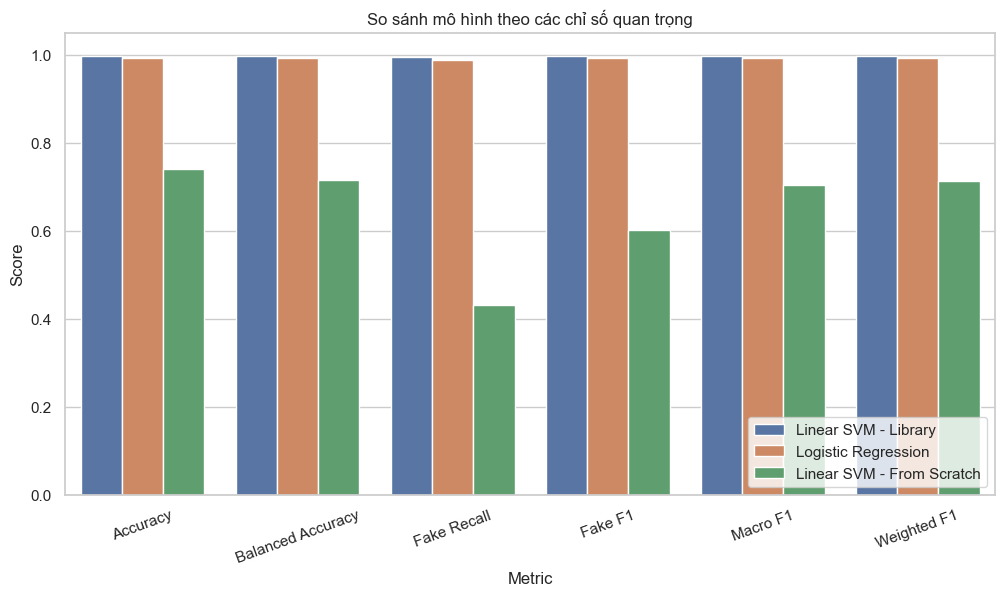

In [31]:

# Biểu đồ so sánh các chỉ số quan trọng hơn cho bài toán phát hiện tin giả
important_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Fake Recall",
    "Fake F1",
    "Macro F1",
    "Weighted F1"
]

plot_df = metrics_df.melt(
    id_vars="Model",
    value_vars=important_metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.title("So sánh mô hình theo các chỉ số quan trọng")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()


In [32]:

# Baseline model: mô hình đoán theo lớp phổ biến nhất
# Dùng để chứng minh mô hình ML thật sự tốt hơn cách đoán đơn giản.

from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB

dummy_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("dummy", DummyClassifier(strategy="most_frequent"))
])

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("nb", MultinomialNB(alpha=0.5))
])

dummy_pipeline.fit(x_train, y_train)
nb_pipeline.fit(x_train, y_train)

y_pred_dummy = dummy_pipeline.predict(x_test)
y_pred_nb = nb_pipeline.predict(x_test)

extra_metrics = []
extra_metrics.append(evaluate_binary_model("Dummy Baseline", y_test, y_pred_dummy))
extra_metrics.append(evaluate_binary_model("Multinomial Naive Bayes", y_test, y_pred_nb))

extra_metrics_df = pd.DataFrame(extra_metrics)
display(extra_metrics_df)

# Gộp bảng so sánh đầy đủ
full_metrics_df = pd.concat([metrics_df, extra_metrics_df], ignore_index=True)
display(full_metrics_df[[
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "Fake Recall",
    "Fake F1",
    "Real Recall",
    "Real F1",
    "Macro F1"
]])



===== Dummy Baseline =====
              precision    recall  f1-score   support

        Fake   0.000000  0.000000  0.000000      4477
        Real   0.542089  1.000000  0.703058      5300

    accuracy                       0.542089      9777
   macro avg   0.271044  0.500000  0.351529      9777
weighted avg   0.293860  0.542089  0.381120      9777


===== Multinomial Naive Bayes =====
              precision    recall  f1-score   support

        Fake   0.955397  0.956891  0.956143      4477
        Real   0.963537  0.962264  0.962900      5300

    accuracy                       0.959804      9777
   macro avg   0.959467  0.959577  0.959522      9777
weighted avg   0.959809  0.959804  0.959806      9777



,Model,Accuracy,Balanced Accuracy,Fake Precision,Fake Recall,Fake F1,Real Precision,Real Recall,Real F1,Macro F1,Weighted F1
0,Dummy Baseline,0.542089,0.500000,0.000000,0.000000,0.000000,0.542089,1.000000,0.703058,0.351529,0.381120
1,Multinomial Naive Bayes,0.959804,0.959577,0.955397,0.956891,0.956143,0.963537,0.962264,0.962900,0.959522,0.959806


,Model,Accuracy,Balanced Accuracy,Fake Recall,Fake F1,Real Recall,Real F1,Macro F1
0,Linear SVM - Library,0.997034,0.996900,0.995309,0.996757,0.998491,0.997268,0.997012
1,Logistic Regression,0.992022,0.991636,0.987045,0.991252,0.996226,0.992668,0.991960
2,Linear SVM - From Scratch,0.739184,0.715211,0.430422,0.601811,1.000000,0.806084,0.703948
3,Dummy Baseline,0.542089,0.500000,0.000000,0.000000,1.000000,0.703058,0.351529
4,Multinomial Naive Bayes,0.959804,0.959577,0.956891,0.956143,0.962264,0.962900,0.959522


In [33]:

# GridSearchCV nên tối ưu bằng macro_f1 hoặc fake_f1 thay vì scoring="f1".
# scoring="f1" mặc định chỉ tối ưu lớp 1, tức Real, nên dễ gây hiểu nhầm trong bài Fake News Detection.

from sklearn.metrics import make_scorer

fake_f1_scorer = make_scorer(f1_score, pos_label=0, zero_division=0)
fake_recall_scorer = make_scorer(recall_score, pos_label=0, zero_division=0)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "fake_f1": fake_f1_scorer,
    "fake_recall": fake_recall_scorer
}

# Đặt True nếu muốn chạy lại GridSearch đầy đủ.
# Cell này có thể chạy lâu vì phải thử nhiều tổ hợp tham số.
RUN_HEAVY_TUNING = False

if RUN_HEAVY_TUNING:
    grid_search_macro = GridSearchCV(
        estimator=svm_pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit="macro_f1",    # Có thể đổi thành "fake_f1" nếu muốn ưu tiên phát hiện Fake
        cv=5,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    grid_search_macro.fit(x_train, y_train)

    print("Best params:")
    print(grid_search_macro.best_params_)

    print("\nBest macro_f1:")
    print(grid_search_macro.best_score_)

    best_svm_macro_model = grid_search_macro.best_estimator_
    y_pred_svm_macro = best_svm_macro_model.predict(x_test)

    evaluate_binary_model("Linear SVM - GridSearch Macro F1", y_test, y_pred_svm_macro)

    cv_results_df = pd.DataFrame(grid_search_macro.cv_results_)
    display(cv_results_df[[
        "params",
        "mean_test_accuracy",
        "mean_test_macro_f1",
        "mean_test_fake_f1",
        "mean_test_fake_recall",
        "rank_test_macro_f1"
    ]].sort_values("rank_test_macro_f1").head(10))
else:
    print("Để chạy GridSearch tối ưu theo macro_f1/fake_f1, đổi RUN_HEAVY_TUNING = True rồi chạy lại cell này.")


Để chạy GridSearch tối ưu theo macro_f1/fake_f1, đổi RUN_HEAVY_TUNING = True rồi chạy lại cell này.


In [34]:

# Linear SVM From Scratch - phiên bản v2
# Cải tiến:
# - Tách alpha cho regularization thay vì dùng 0.5 * ||w||^2 quá mạnh.
# - Learning-rate decay để SGD ổn định hơn.
# - Tách validation set để chọn threshold tối ưu theo macro_f1 hoặc fake_f1.
# - In riêng Fake Recall/Fake F1 để tránh hiểu nhầm metric của lớp Real.

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

class LinearSVMFromScratchV2:
    def __init__(
        self,
        learning_rate=0.05,
        lr_decay=0.03,
        C=1.0,
        alpha=1e-4,
        n_epochs=80,
        batch_size=1024,
        random_state=42,
        class_weight="balanced",
        threshold_objective="macro_f1"
    ):
        self.learning_rate = learning_rate
        self.lr_decay = lr_decay
        self.C = C
        self.alpha = alpha
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.class_weight = class_weight
        self.threshold_objective = threshold_objective

        self.w = None
        self.b = 0.0
        self.threshold_ = 0.0
        self.loss_history = []

    def _convert_labels(self, y):
        y = np.asarray(y)
        return np.where(y == 1, 1, -1)

    def _compute_sample_weights(self, y_signed):
        if self.class_weight != "balanced":
            return np.ones_like(y_signed, dtype=float)

        n_samples = len(y_signed)
        n_pos = np.sum(y_signed == 1)
        n_neg = np.sum(y_signed == -1)

        weight_pos = n_samples / (2 * n_pos)
        weight_neg = n_samples / (2 * n_neg)

        return np.where(y_signed == 1, weight_pos, weight_neg)

    def _compute_loss(self, X, y_signed, sample_weights):
        margins = y_signed * (X @ self.w + self.b)
        hinge_loss = np.maximum(0, 1 - margins)
        weighted_hinge_loss = np.mean(sample_weights * hinge_loss)
        regularization_loss = 0.5 * self.alpha * np.dot(self.w, self.w)
        return regularization_loss + self.C * weighted_hinge_loss

    def fit(self, X, y, verbose=True):
        y_signed = self._convert_labels(y)
        sample_weights = self._compute_sample_weights(y_signed)

        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)

        self.w = np.zeros(n_features)
        self.b = 0.0
        self.threshold_ = 0.0
        self.loss_history = []

        for epoch in range(self.n_epochs):
            lr = self.learning_rate / (1.0 + self.lr_decay * epoch)
            indices = rng.permutation(n_samples)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]

                X_batch = X[batch_idx]
                y_batch = y_signed[batch_idx]
                weights_batch = sample_weights[batch_idx]

                scores = X_batch @ self.w + self.b
                margins = y_batch * scores
                violations = margins < 1

                # Regularization chỉ tác động lên w, không tác động lên b.
                w_grad = self.alpha * self.w
                b_grad = 0.0

                if np.any(violations):
                    X_vio = X_batch[violations]
                    y_vio = y_batch[violations]
                    weights_vio = weights_batch[violations]

                    weighted_y = weights_vio * y_vio

                    hinge_w_grad = X_vio.T @ weighted_y
                    hinge_w_grad = np.asarray(hinge_w_grad).ravel()
                    hinge_b_grad = np.sum(weighted_y)

                    n_batch = len(batch_idx)

                    w_grad -= self.C * hinge_w_grad / n_batch
                    b_grad -= self.C * hinge_b_grad / n_batch

                self.w -= lr * w_grad
                self.b -= lr * b_grad

            epoch_loss = self._compute_loss(X, y_signed, sample_weights)
            self.loss_history.append(epoch_loss)

            if verbose and ((epoch + 1) % 5 == 0 or epoch == 0):
                print(f"Epoch {epoch + 1}/{self.n_epochs} - lr={lr:.5f} - loss={epoch_loss:.6f}")

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def tune_threshold(self, X_val, y_val, n_thresholds=101):
        scores = np.asarray(self.decision_function(X_val)).ravel()

        thresholds = np.linspace(np.percentile(scores, 5), np.percentile(scores, 95), n_thresholds)

        best_threshold = 0.0
        best_score = -1.0

        for threshold in thresholds:
            y_pred = np.where(scores >= threshold, 1, 0)

            if self.threshold_objective == "fake_f1":
                score = f1_score(y_val, y_pred, pos_label=0, zero_division=0)
            else:
                score = f1_score(y_val, y_pred, average="macro", zero_division=0)

            if score > best_score:
                best_score = score
                best_threshold = threshold

        self.threshold_ = best_threshold

        print(f"Best threshold: {self.threshold_:.6f}")
        print(f"Best validation {self.threshold_objective}: {best_score:.6f}")

        return self

    def predict(self, X):
        scores = np.asarray(self.decision_function(X)).ravel()
        return np.where(scores >= self.threshold_, 1, 0)


# Tách validation từ train để chọn threshold cho SVM tự code
x_train_scratch_text, x_val_scratch_text, y_train_scratch_v2, y_val_scratch_v2 = train_test_split(
    x_train,
    y_train,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train
)

tfidf_svm_scratch_v2 = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_scratch_v2 = tfidf_svm_scratch_v2.fit_transform(x_train_scratch_text)
X_val_scratch_v2 = tfidf_svm_scratch_v2.transform(x_val_scratch_text)
X_test_scratch_v2 = tfidf_svm_scratch_v2.transform(x_test)

svm_scratch_v2 = LinearSVMFromScratchV2(
    learning_rate=0.05,
    lr_decay=0.03,
    C=1.0,
    alpha=1e-4,
    n_epochs=80,
    batch_size=1024,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    threshold_objective="macro_f1"   # đổi thành "fake_f1" nếu muốn ưu tiên phát hiện Fake
)

svm_scratch_v2.fit(X_train_scratch_v2, y_train_scratch_v2, verbose=True)
svm_scratch_v2.tune_threshold(X_val_scratch_v2, y_val_scratch_v2)

y_pred_svm_scratch_v2 = svm_scratch_v2.predict(X_test_scratch_v2)

evaluate_binary_model("Linear SVM - From Scratch V2", y_test, y_pred_svm_scratch_v2)

print("Số lượng nhãn dự đoán:")
print(pd.Series(y_pred_svm_scratch_v2).value_counts().sort_index())


KeyboardInterrupt: 

## Gợi ý viết nhận xét trong báo cáo

Có thể thêm đoạn sau vào phần đánh giá:

> Ngoài Accuracy, nhóm sử dụng thêm Macro F1, Balanced Accuracy, Fake Recall và Fake F1 để đánh giá mô hình. Lý do là trong bài toán phát hiện tin giả, nếu chỉ dùng Accuracy hoặc F1 mặc định của `sklearn`, mô hình có thể bị đánh giá thiên về lớp `Real` do `pos_label=1`. Vì mục tiêu chính là phát hiện tin giả, nhóm ưu tiên quan sát khả năng nhận diện lớp `Fake`, đặc biệt là `Fake Recall` và `Fake F1`.

Với phần SVM from scratch, có thể viết:

> Mô hình Linear SVM from scratch được xây dựng nhằm minh họa quá trình tối ưu hinge loss bằng mini-batch gradient descent. Kết quả có thể thấp hơn `LinearSVC` của thư viện vì `LinearSVC` được tối ưu hóa ở mức thuật toán và cài đặt, trong khi bản from scratch chủ yếu phục vụ mục đích giải thích nguyên lý hoạt động.
